# Fractional Brownian Motion Parameter Estimation Using Periodogram Method

The periodigram method uses the fractional brownian noise power spectrum to estimate the Hurst, denoted by $H$. The power spectrum is the Fourier transform of the fractional brownian motion noise autocorrelation function. This relationship is called the Weiner-Khichnin theorem.</br>

Let $Z^H(t)$ denote a fractional path then fractional brownian noise is defined by,

$
\begin{align}
\Delta Z_k^H = Z^H(t_k) - Z^H(t_{k-1})
\end{align}
\tag{1}
$

where $t_k = k \Delta t$. It follows that,

$
\begin{align}
Z^H(n\Delta t) = \sum_{i=1}^n \Delta Z_k^H
\end{align}
\tag{2}
$

The autocovariance of fractional brownian noise is given by,

$
\begin{align}
\gamma^H_n = \text{Cov}[\Delta Z^H_t \Delta Z^H_{t+n}] = \frac{1}{2}\Delta t^{2H}[(n-1)^{2H} + (n+1)^{2H} - 2n^{2H}]
\end{align}
\tag{3}
$

Since $\text{Var}(\Delta Z_k^H) = \Delta t^{2H}$ the autocorrelation coefficient is defined by,</br>

$
\begin{align}
\rho^H_n = \frac{\gamma^H_n}{\Delta t^{2H}} = \frac{1}{2}[(n-1)^{2H} + (n+1)^{2H} - 2n^{2H}]
\end{align}
\tag{4}
$

From the Weiner-Khichnin theorem the power spectrum is given by,</br>

$
\begin{align}
\hat{\rho}^H_\omega = \frac{1}{2} \int_{-\infty}^{\infty} \rho^H_n e^{-i \omega n} dn
\end{align}
\tag{5}
$

It can be shown that fir $\omega \gg 1$,

$
\begin{align}
\hat{\rho}^H_\omega \approx C\lvert \omega \rvert^{1 - 2H}
\end{align}
\tag{6}
$

where $C$ is independent of $\omega$. It follows that $H$ can be determined by using OLS on $\hat{\rho}^H_\omega$ as a< function of $\omega$.

## Imports

In [13]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import fbm, stats
from lib.plots import periodogram, curve, PlotType

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [14]:
npts = 2**10

## Power Spectrum Simulation H=0.8

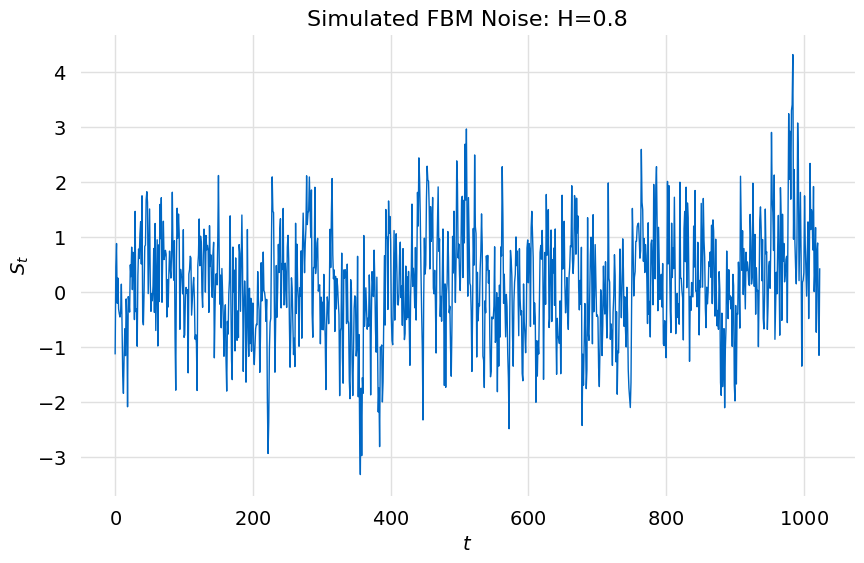

In [15]:
H = 0.8
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

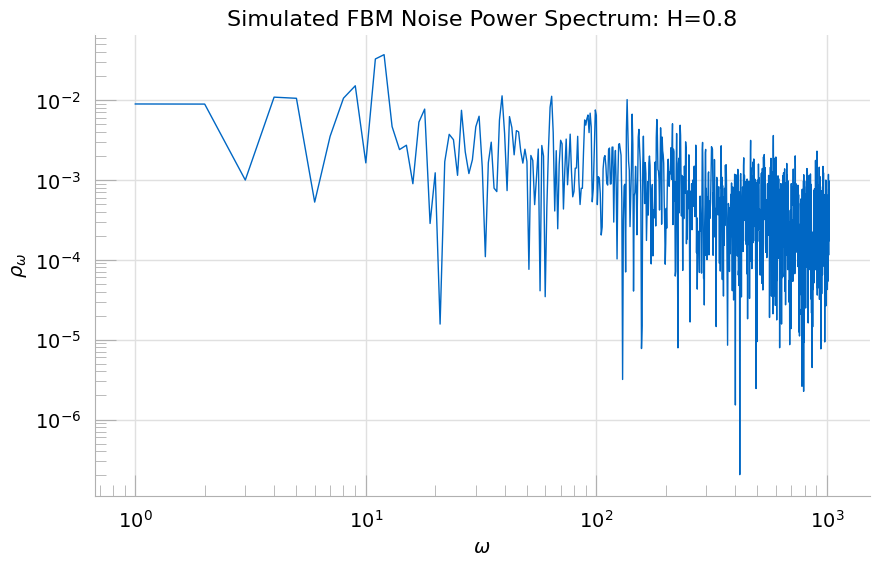

In [16]:
freq, ps = stats.compute_pspec(t, fbm_noise)

title = f"Simulated FBM Noise Power Spectrum: H={H}"
curve(ps, freq, lw=1, title=title, xlabel=r"$\omega$", ylabel=r"$\rho_\omega$", plot_axis_type=PlotType.LOG)

In [17]:
result, result_model = fbm.compute_H_estimate_periodogram(freq, ps)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.204
Model:                            OLS   Adj. R-squared:                  0.203
Method:                 Least Squares   F-statistic:                     261.9
Date:                Sat, 30 Sep 2023   Prob (F-statistic):           1.32e-52
Time:                        18:39:45   Log-Likelihood:                -831.43
No. Observations:                1023   AIC:                             1667.
Df Residuals:                    1021   BIC:                             1677.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.7203      0.104    -16.505      0.000      -1.925      -1.516
x1            -0.6456      0.040    -16.183      0.000      -0.724      -0.567
==============================================================================
Omnibus:                      235.342   Durbin-Watson:                   1.518
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              569.861
Skew:                          -1.222   Prob(JB):                    1.80e-124
Kurtosis:                       5.720   Cond. No.                         18.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [18]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -1.7203493375857508,
      "err": 0.10422908986509631,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "ccaed1c0-4d7b-4ac0-8c4d-d4244d431f9b",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -0.6455732038959576,
         "err": 0.03989299466174018,
         "est_label": null,
         "err_label": null,
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "ccaed1c0-4d7b-4ac0-8c4d-d4244d431f9b",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.2041327196909284,
   "param_transforms": [
      {
         "param": {
            "est": 0.8227866019479788,
            "err": 0.01994649733087009,
            "est_label": "$\\hat{\u0397}$",
            "err_label": "$\\sigma_{\\hat{\u0397}}$",
            "row": 0,
            "column": 0,
            "order": 1,
            "est_id": "ccaed1c0-4d7b-4ac0-8

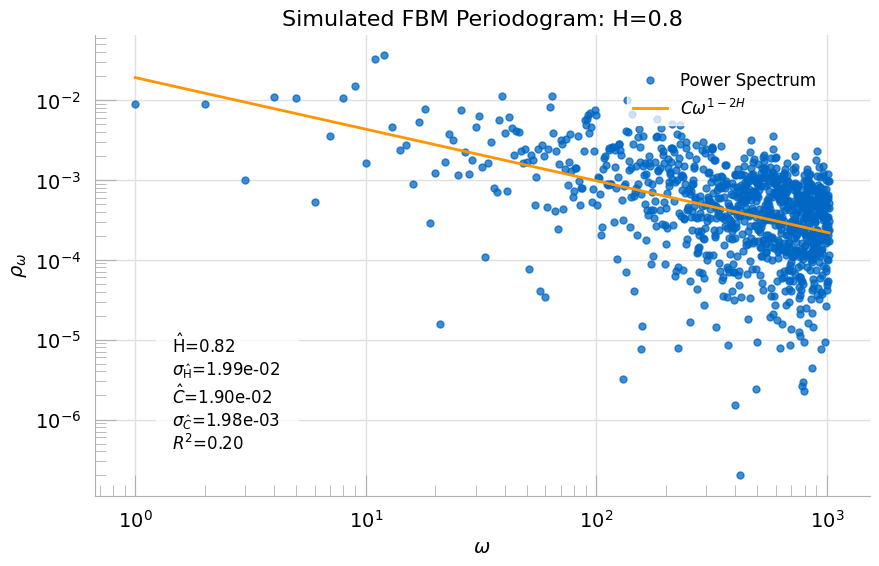

In [19]:
periodogram(ps, result_model, freq, title=f"Simulated FBM Periodogram: H={H}")

## Power Spectrum Simulation H=0.3

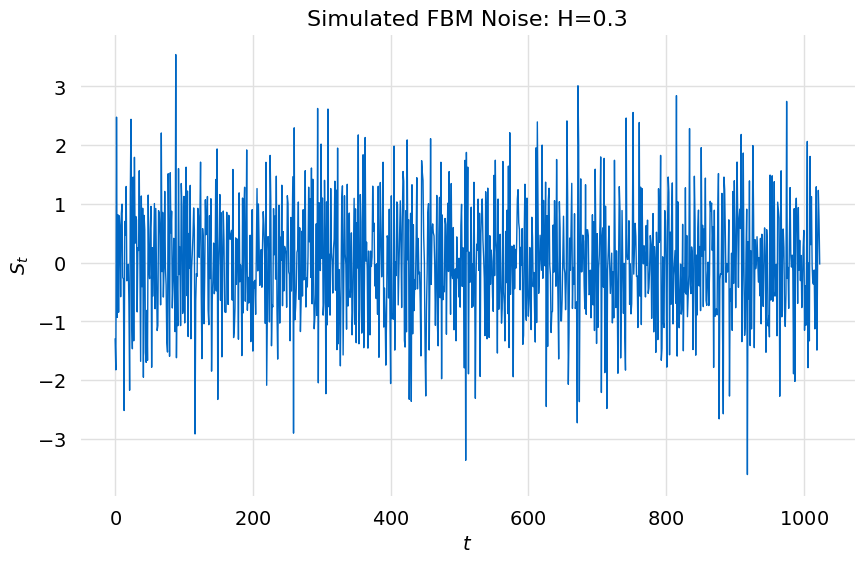

In [20]:
H = 0.3
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

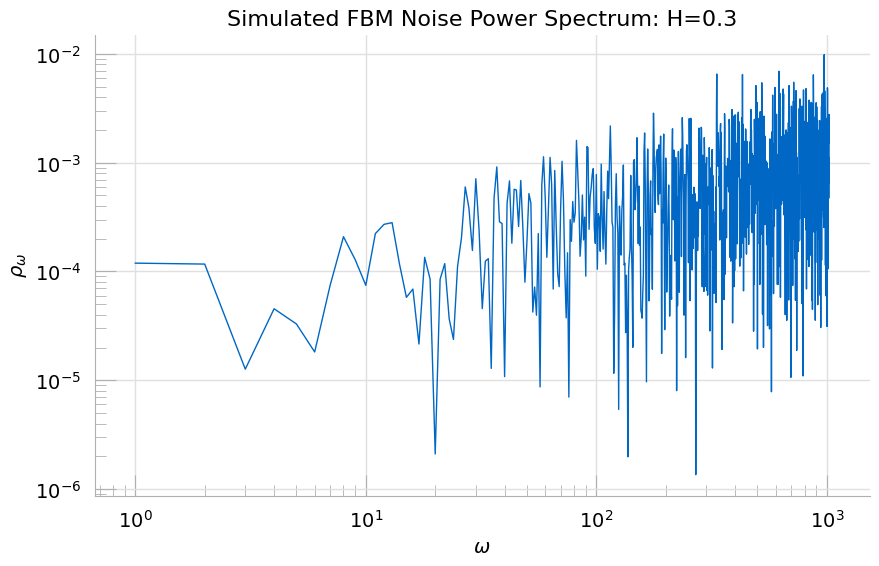

In [21]:
freq, ps = stats.compute_pspec(t, fbm_noise)

title = f"Simulated FBM Noise Power Spectrum: H={H}"
curve(ps, freq, lw=1, title=title, xlabel=r"$\omega$", ylabel=r"$\rho_\omega$", plot_axis_type=PlotType.LOG)

In [22]:
result, result_model = fbm.compute_H_estimate_periodogram(freq, ps)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     175.1
Date:                Sat, 30 Sep 2023   Prob (F-statistic):           5.19e-37
Time:                        18:39:47   Log-Likelihood:                -806.31
No. Observations:                1023   AIC:                             1617.
Df Residuals:                    1021   BIC:                             1626.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.6214      0.102    -45.441      0.000      -4.821      -4.422
x1             0.5151      0.039     13.233      0.000       0.439       0.591
==============================================================================
Omnibus:                      124.970   Durbin-Watson:                   1.436
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              180.869
Skew:                          -0.881   Prob(JB):                     5.31e-40
Kurtosis:                       4.067   Cond. No.                         18.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [23]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -4.621384914970106,
      "err": 0.10170094245030324,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "c150c1cc-e493-49d4-b05c-e661ca7ef8e1",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.5151144672455903,
         "err": 0.03892536296263421,
         "est_label": null,
         "err_label": null,
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "c150c1cc-e493-49d4-b05c-e661ca7ef8e1",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.14640855801697694,
   "param_transforms": [
      {
         "param": {
            "est": 0.24244276637720485,
            "err": 0.019462681481317103,
            "est_label": "$\\hat{\u0397}$",
            "err_label": "$\\sigma_{\\hat{\u0397}}$",
            "row": 0,
            "column": 0,
            "order": 1,
            "est_id": "c150c1cc-e493-49d4-

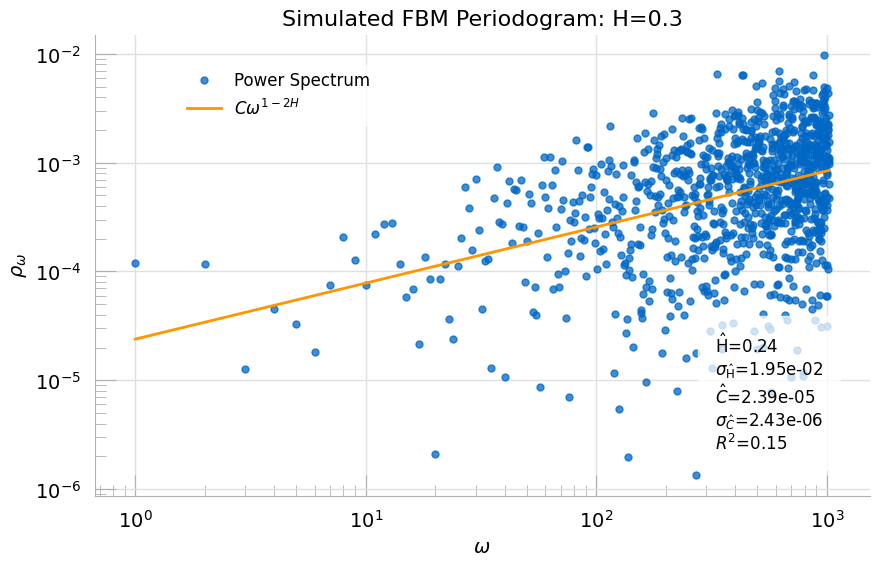

In [24]:
periodogram(ps, result_model, freq, title=f"Simulated FBM Periodogram: H={H}")